# Chapter 12 example: closing an integrality gap

A local MAP-LP may be fractional because it enforces only low-order consistency. A central strategy is to add valid constraints or larger regions until the fractional optimum is excluded.

We use the frustrated triangle from the first notebook. The base LP has a fractional optimum. Adding one **cycle consistency** constraint is enough to recover the exact MAP value. This is the smallest illustration of the logic behind cutting planes, cycle inequalities, and Sherali--Adams-type tightening.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from itertools import product
from scipy.optimize import minimize, linprog

CWD=Path.cwd()
NOTEBOOK_DIR=CWD if CWD.name.startswith('ch') else CWD/'notebooks'/CWD.name if False else CWD
if not (NOTEBOOK_DIR/'figs').exists() and (CWD/'notebooks').exists():
    # infer chapter directory from notebook working directory only when launched at repo root
    raise RuntimeError('Run this notebook from its chapter directory, e.g. notebooks/ch10/.')
FIG_DIR=NOTEBOOK_DIR/'figs'; FIG_DIR.mkdir(parents=True,exist_ok=True)
RNG=np.random.default_rng(577)
NODE_COLOR='#34495e'
plt.rcParams.update({'font.size':14,'axes.titlesize':17,'axes.labelsize':15,'xtick.labelsize':12,'ytick.labelsize':12,'legend.fontsize':12})
def save_figure(fig,stem):
    fig.savefig(FIG_DIR/f'{stem}.pdf',bbox_inches='tight')
    fig.savefig(FIG_DIR/f'{stem}.png',dpi=220,bbox_inches='tight')

In [2]:
# Correlation formulation for a frustrated triangle.
# y_e = probability that endpoints disagree. For three binary labels, y must lie in the cut polytope.
# Local relaxation: 0<=y_e<=1. Objective favors y01=0,y12=0,y02=1, impossible simultaneously.
c=np.array([1.,1.,-1.]) # energy up to an additive constant, minimize
base=linprog(c,bounds=[(0,1)]*3,method='highs')
# Triangle cut inequalities: y02 <= y01+y12 and permutations; plus y01+y12+y02<=2
Aub=np.array([[-1,-1,1],[-1,1,-1],[1,-1,-1],[1,1,1]])
bub=np.array([0,0,0,2])
tight=linprog(c,A_ub=Aub,b_ub=bub,bounds=[(0,1)]*3,method='highs')
print('base LP',base.fun,base.x); print('tightened LP',tight.fun,tight.x)
# exact binary assignments
states=np.array(list(product([0,1],repeat=3))); Y=np.column_stack([states[:,0]!=states[:,1],states[:,1]!=states[:,2],states[:,0]!=states[:,2]]).astype(float); vals=Y@c
print('exact',vals.min(),Y[vals.argmin()])

base LP -1.0 [0. 0. 1.]
tightened LP 0.0 [1. 0. 1.]
exact 0.0 [0. 0. 0.]


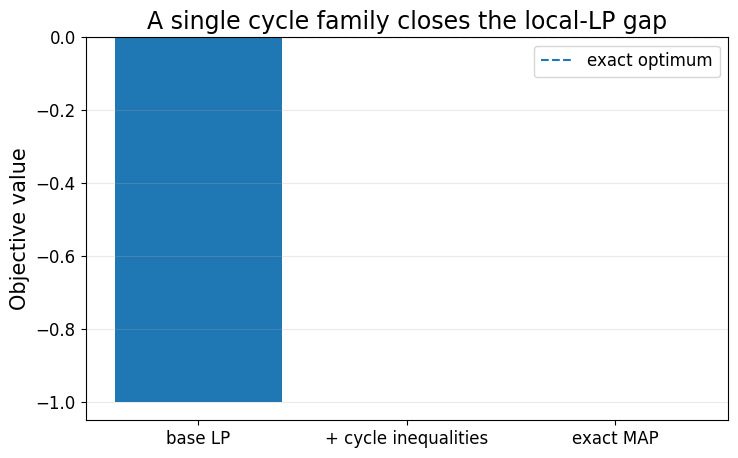

In [3]:
fig,ax=plt.subplots(figsize=(7.6,4.8)); labels=['base LP','+ cycle inequalities','exact MAP']; vals=[base.fun,tight.fun,vals.min()]; bars=ax.bar(labels,vals); ax.axhline(vals[-1],linestyle='--',linewidth=1.5,label='exact optimum'); ax.set_ylabel('Objective value'); ax.set_title('A single cycle family closes the local-LP gap'); ax.legend(); ax.grid(axis='y',alpha=.25); fig.tight_layout(); save_figure(fig,'ch12_03_tightening_closes_gap'); plt.show()

## Exercises

1. Identify which triangle inequality is violated by the base LP optimum.
2. Repeat the experiment for an odd cycle of length five. Add cycle inequalities incrementally and monitor the LP bound.
3. **Challenge.** Design a cutting-plane loop: solve the current LP, detect a violated cycle inequality, add it, and repeat until no violation remains.